### 4. Submission 4. Number of Change-of-mind

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import Normalize
from scipy import stats
import starbars

cmap = mpl.colormaps['cool']

In [6]:
from spyglass.shijiegu.Analysis_SGU import ChangeofMind
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.shijiegu.behavior import get_com_num_animal

[2026-05-22 13:23:32,374][WARNING]: Reconnecting to MySQL server.
[13:23:33][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[13:23:33][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[13:23:33][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[13:23:33][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.co

In [7]:
# import os
# import datajoint as dj

# from spyglass.common.common_usage import Export, ExportSelection
# paper_key = {"paper_id": "Gu2026"}

# ExportSelection().start_export(**paper_key, analysis_id="behavior_num_of_com")

In [8]:
list_of_days_animals = {}
seq_animals = {}

animal = "molly"
list_of_days_animals[animal]  = ['20220415','20220416','20220417','20220418','20220419','20220420']

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109','20240110']

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']

In [23]:
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure1'
for animal in ["molly", "lewis", "eliot", 'julio', "klein"]:#list_of_days_animals.keys():
    com_num = get_com_num_animal(animal, list_of_days_animals[animal], proportion_threshold = 0.1)

    file_path = f"{output_folder}/com_number_{animal}.pickle"
    
    data = {"com_num": com_num}
    
    with open(file_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Data successfully pickled and saved to {file_path}")

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/com_number_molly.pickle
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/com_number_lewis.pickle
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/com_number_eliot.pickle
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/com_number_julio.pickle
Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/com_number_klein.pickle


### plotting

In [10]:
from spyglass.shijiegu.changeOfMind import color_by_rat

Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/com_number_molly.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/com_number_eliot.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/com_number_julio.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/com_number_klein.pickle
Data successfully loaded from /stelmo/shijie/change_of_mind_analysis/figure1/com_number_lewis.pickle


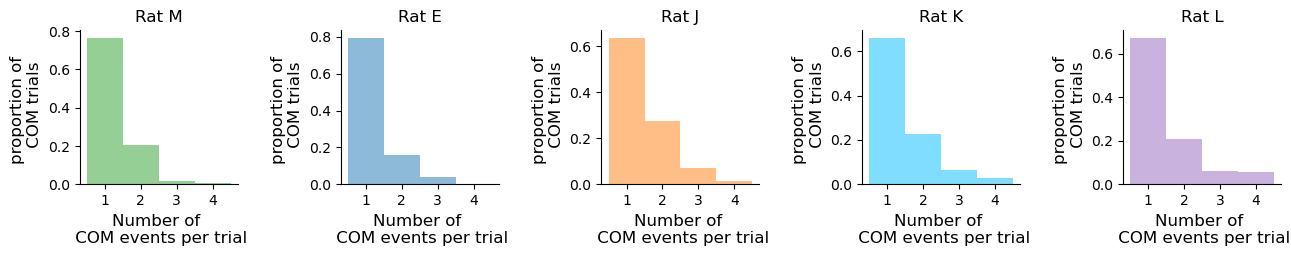

In [24]:
animals = ["molly", "eliot", "julio" ,"klein", "lewis"]
fig, axes = plt.subplots(1,len(animals), figsize = (2.5*len(animals) + 3,2))
plt.subplots_adjust(wspace=0.65)

animal_ind = 0
for animal in animals:

    ### load data
    file_path = f"{output_folder}/com_number_{animal}.pickle"

    with open(file_path, 'rb') as file:
        data = pickle.load(file)
        print(f"Data successfully loaded from {file_path}")

    com_num = data["com_num"]
    axes[animal_ind].hist(com_num, bins = [1,2,3,4,5],
                          color = color_by_rat[animal], alpha = 0.5,
                          weights = np.ones(len(com_num))/len(com_num))
    axes[animal_ind].set_xticks(np.array([1,2,3,4]) + 0.5)
    axes[animal_ind].set_xticklabels(np.array([1,2,3,4]))
    axes[animal_ind].set_title(f"Rat {animal[0].upper()}")
    axes[animal_ind].set_xlabel("Number of \n COM events per trial", fontsize = 12)
    axes[animal_ind].set_ylabel("proportion of \n COM trials", fontsize = 12)
    axes[animal_ind].spines['right'].set_visible(False)
    axes[animal_ind].spines['top'].set_visible(False)

    animal_ind += 1

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure1/number_of_com"
#plt.savefig(file_path + ".pdf",bbox_inches='tight')
#plt.savefig(file_path + ".png")   


In [11]:
# ExportSelection().stop_export(**paper_key, analysis_id="behavior_num_of_com")